In [1]:
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm


In [ ]:
import scqubits
def second_order_derivative(f, x0, rtol=1e-3, atol=1e-4, max_iter=20):
    h = 1e-3
    derivative_old = 0.0
    print('\n')
    for i in range(max_iter):
        h /= 2
        derivative_new = (f(x0 + h) - 2 * f(x0) + f(x0 - h)) / h**2
        print(derivative_new)
        if np.abs(derivative_new - derivative_old) < rtol*np.abs(derivative_old):
            return derivative_new
        derivative_old = derivative_new
    raise ValueError("Convergence not reached within the maximum number of iterations")


def get_frequency(flux,EJ,EC,EL,i,j):
    qbt = scqubits.Fluxonium(EJ = EJ,EC = EC,EL =EL, cutoff = 110,flux = flux,truncated_dim=20)
    vals = qbt.eigenvals()
    return np.abs(vals[j]-vals[i])


In [92]:
EJ = 3
EJ_over_EL_list = np.linspace(20,30,41)
EJ_over_EC_list = np.linspace(2,10,41)

import pickle
with open('data_v3.data', 'rb') as f:
    (EJ_over_EL_list, EJ_over_EC_list, EJ_over_EC_array, EJ_over_EL_array,
                 upside_down_phi_element01_array , upside_down_phi_element12_array ,
                   upside_down_freq01_array , upside_down_freq12_array ,
                     conventional_phi_element_array ,conventional_freq_array ,
                    upside_down_2nd_order_01_array ,upside_down_2nd_order_12_array ,conventional_2nd_order_array   ) = pickle.load(f)


hbar = 1/(2*np.pi)
def one_over_f_loss_rate(omega, EL, phi_element, one_over_f_flux_noise_amplitude):
    return_val = 8 * np.pi**3  # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val *= (phi_element)**2 / omega  # GHz
    return return_val

def dielectric_loss_rate(omega, EC, phi_element, Q_cap):
    temp_in_mK = 42  # K
    kB = 8.617333262e-5  # eV K−1
    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    return_val = hbar * omega**2  # h*GHZ^2
    return_val /= (4 * EC * Q_cap)  # GHZ
    return_val *= phi_element**2  # GHZ

    hbar_in_eVs = 6.5821e-16  # eV s
    coth_arg = beta * hbar_in_eVs * omega / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val *= 1 / np.tanh(coth_arg)  # GHZ
    return return_val

def T_phi(second_order_derivative, one_over_f_flux_noise_amplitude):  # eqn (13) of Peter Groszkowski et al 2018 New J. Phys. 20 043053
    omega_uv = 3 * 2 * np.pi  # GHz
    omega_ir = 1e-9 * 2 * np.pi  # GHz
    t = 10e3  # ns
    A = one_over_f_flux_noise_amplitude  # in unit of Phi0
    return_val = 2 * A**4 * second_order_derivative**2  # Phi0^4 GHZ^2 / Phi0^4
    return_val *= (np.log(omega_uv / omega_ir)**2 + 2 * np.log(omega_ir * t)**2)  # GHZ^2
    return_val = return_val**(-1/2)  # ns
    return return_val  # ns


In [137]:
# one_over_f_flux_noise_amplitude = 1e-6
# Q_cap = 2.5e5

one_over_f_flux_noise_amplitude = 4e-6
Q_cap = 1e6

Tphi = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
upside_down12_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
upside_down12_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
for i in range(len(EJ_over_EL_list)):
    for j in range(len(EJ_over_EC_list)):
        EL = EJ / EJ_over_EL_list[i]
        EC = EJ / EJ_over_EC_list[j]
        second_order_upside_down01 = upside_down_2nd_order_01_array[i, j]
        second_order_upside_down12 = upside_down_2nd_order_12_array[i, j]
        Tphi[i, j] = T_phi(second_order_upside_down01+second_order_upside_down12, 
                           one_over_f_flux_noise_amplitude)
        
        omega_upside_down12 = upside_down_freq12_array[i, j] * 2 * np.pi
        phi_upside_down12 = upside_down_phi_element12_array[i, j]
        upside_down12_dielectric_lifetime[i, j] = 1 / dielectric_loss_rate(omega_upside_down12, EC, phi_upside_down12, Q_cap)
        upside_down12_one_over_f_loss_lifetime[i, j] = 1 / one_over_f_loss_rate(omega_upside_down12, EL, phi_upside_down12, one_over_f_flux_noise_amplitude)

T1ef = 2/(1/upside_down12_one_over_f_loss_lifetime + \
             1/upside_down12_dielectric_lifetime)/1e6 # milisecond
Tphi =  Tphi / 1e6 # milisecond which is 1e-3 second

/tmp/ipykernel_1227993/83232032.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 1])


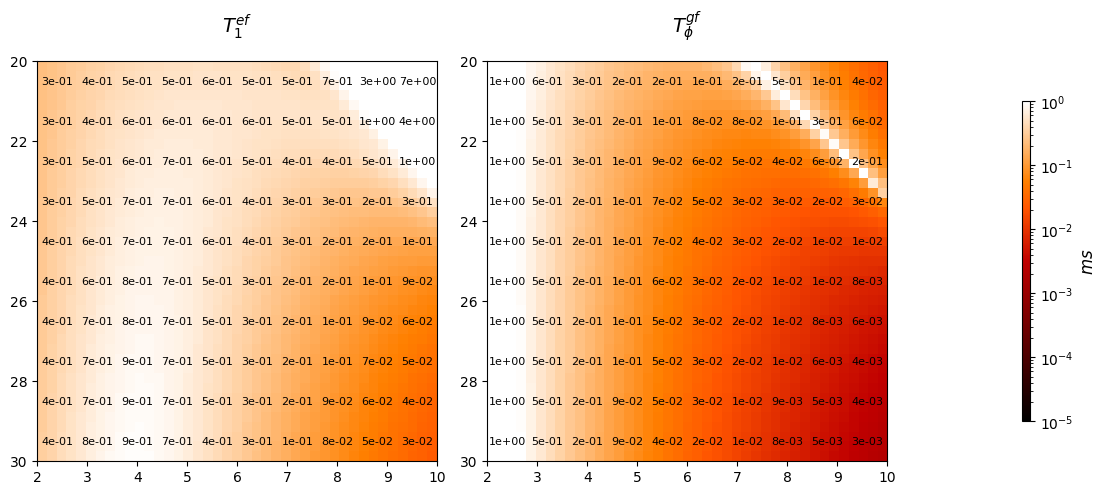

In [219]:
cmap = plt.get_cmap('gist_heat')
norm =  LogNorm(1e-5, 1)
fig = plt.figure(figsize = (10,4))
# plt.title('f')
ax1 = fig.add_axes([0, 0, 0.4, 1])
ax2 = fig.add_axes([0.45, 0, 0.4, 1])
cbar_ax = fig.add_axes([0.9, 0, 0.1, 1])
cbar_ax.axis('off')
for ax, data, title in zip([ax1,ax2], [T1ef, Tphi], ['$T_1^{{ef}}$', rf'$T_\phi^{{gf}}$']):
    ax.set_title(title, y=1.05, size=14)
    # data_trunc = data[:,:31]
    im = ax.imshow(data, 
                   extent=[ EJ_over_EC_list.min(), EJ_over_EC_list.max(),
                           EJ_over_EL_list.max(), EJ_over_EL_list.min(),
                            ],
                   cmap=cmap, norm=norm, aspect='auto')
    # ax.set_aspect('equal')
    for i in range(data.shape[0])[2::4]:
        for j in range(data.shape[1])[2::4]:
            ax.text(EJ_over_EC_list[i], 
                    EJ_over_EL_list[ j],f"{data[j,i]:.0e}",ha='center',va='center',size=8)

cbar = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),ax=cbar_ax,  shrink=0.8, aspect=40, pad=0.02)
cbar.set_label(rf'$ms$', size=12)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

# Assume a gate time of 200 ns

/tmp/ipykernel_1227993/2717663063.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 1])


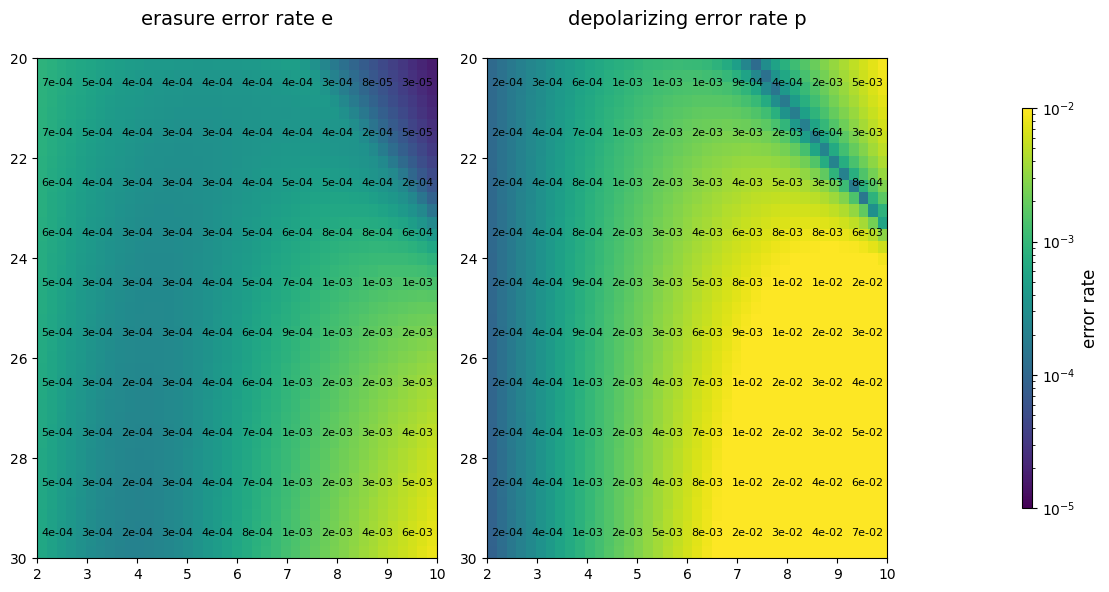

In [222]:
cmap = plt.get_cmap('viridis')
norm =  LogNorm(1e-5, 1e-2)

X, Y = np.meshgrid(EJ_over_EC_list,EJ_over_EL_list)
fig = plt.figure(figsize = (10,5))
# plt.title('f')

ax1 = fig.add_axes([0, 0, 0.4, 1])
ax2 = fig.add_axes([0.45, 0, 0.4, 1])
cbar_ax = fig.add_axes([0.9, 0, 0.1, 1])
cbar_ax.axis('off')

for ax, data, title in zip([ax1,ax2], [T1ef, Tphi], ['erasure error rate e', rf'depolarizing error rate p']):

    new_data = 200*1e-6/data
    ax.set_title(title, y=1.05, size=14)
    im = ax.imshow(new_data, 
                   extent=[ EJ_over_EC_list.min(), EJ_over_EC_list.max(),
                           EJ_over_EL_list.max(), EJ_over_EL_list.min(),
                            ],
                   cmap=cmap, norm=norm, aspect='auto')
    ax.set_aspect('equal')

    for i in range(data.shape[0])[2::4]:
        for j in range(data.shape[1])[2::4]:
            ax.text(EJ_over_EC_list[i], 
                    EJ_over_EL_list[ j],f"{new_data[j,i]:.0e}",ha='center',va='center',size=8)

cbar = fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap),ax=cbar_ax,  shrink=0.8, aspect=40, pad=0.02)
cbar.set_label(rf'error rate', size=12)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()